In [3]:
import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt
import torch

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
os.chdir("/content/drive/MyDrive/3. Grad School/리스크 관리 경진대회")

### 데이터 정제

In [ ]:
data_org = pd.read_pickle("DATA/Health_Insurance.pkl")
print(f"데이터 형태 : {data_org.shape}")
data_org.head()

데이터 형태 : (228711, 42)


,ID,ID_policy,ID_insured,period,date_effect_insured,date_lapse_insured,date_effect_policy,date_lapse_policy,year_effect_insured,year_lapse_insured,...,C_H,C_GI,C_II,C_IE_P,C_IE_S,C_IE_T,C_GE_P,C_GE_S,C_GE_T,C_C
0,1_1,1,1,2017,1993-06-15,2017-12-20,1993-06-15,NaT,1993,2017.0,...,H1,99.0,85.0,18.0,52.0,59.0,4.0,14.0,96.0,C6
1,1_2,1,2,2017,1993-06-15,NaT,1993-06-15,NaT,1993,NaN,...,H1,99.0,85.0,18.0,52.0,59.0,4.0,14.0,96.0,C6
2,2_1,2,1,2017,1993-06-16,NaT,1993-06-16,NaT,1993,NaN,...,H6,100.0,94.0,26.0,11.0,85.0,7.0,1.0,100.0,C6
3,3_3,3,3,2017,1993-06-15,NaT,1993-06-15,NaT,1993,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,3_5,3,5,2017,1993-06-15,NaT,1993-06-15,NaT,1993,NaN,...,H6,99.0,81.0,32.0,34.0,69.0,9.0,4.0,98.0,C6


**사용 변수**
- 모델링
    - Y: `lapse`
    - 기본 정보
        - 기존) `premium`, `type_policy_dg`, `type_product`, `new_business`, `cost_claims_year`, `n_medical_services`, `reimbursement`, `distribution_channel`
        - 파생) `help_requested`, `high_loss`, `economic_stress`, `relative_poverty`
    - 나이 관련
        - 기존) `age`, `seniority_insured`, `seniority_policy`, `n_medical_services`
        - 파생) `kr_age_risk`, `kr_premium_shock`
    - 성별 관련
        - 기존) `gender`
    - 지역 관련
        - 기존) `IICIMUN`, `IICIPROV`, `C_C`, `C_H`, `C_GI`, `C_II`, `C_IE_P`, `C_IE_T`, `C_GE_P`, `C_GE_T`
    - 한국 맥락
        - 파생) `kr_retention_years`, `kr_early_laps`, `kr_medical_desert`
        
    

In [ ]:
target = 'lapse'
x_cols = [
    # 기본
    'exposure_time', 'premium', 'seniority_insured', 'seniority_policy', 'type_policy_dg', 'type_product', 'new_business',
    'cost_claims_year', 'n_medical_services', 'reimbursement', 'distribution_channel',
    # 나이 관련
    'age',
    # 성별 관련
    'gender',
    # 지역 관련
    'IICIMUN', 'IICIPROV', 'C_C', 'C_H', 'C_GI', 'C_II', 'C_IE_P', 'C_IE_T', 'C_GE_P', 'C_GE_T'
]
tmp_cols = [
    # 개인 구분
    'ID',
    # 파생변수 생성용
    'period'
]

use_cols = [target] + x_cols + tmp_cols
print(f"사용 변수 개수(기본) : {len(x_cols)}")

사용 변수 개수(기본) : 23


#### 결측치 처리

In [ ]:
print(data_org.isna().sum())
data = data_org[use_cols]

ID                           0
ID_policy                    0
ID_insured                   0
period                       0
date_effect_insured          0
date_lapse_insured      167181
date_effect_policy           0
date_lapse_policy       174568
year_effect_insured          0
year_lapse_insured      167181
year_effect_policy           0
year_lapse_policy       174568
exposure_time                0
lapse                        0
seniority_insured            0
seniority_policy             0
type_policy                  0
type_policy_dg               0
type_product                 0
reimbursement                0
new_business                 0
distribution_channel         0
gender                       0
age                          0
premium                      0
cost_claims_year             0
n_medical_services           0
n_insured_pc                 0
n_insured_mun                0
n_insured_prov               0
IICIMUN                  10886
IICIPROV                  5701
C_H     

- 지역 변수 결측치 -> `context_missing`, `iiciprov_missing` 생성

In [ ]:
# C_C 또는 C_H 하나만 결측인 데이터 제거
c_c_nan = data[data['C_C'].isna() & ~data['C_GI'].isna()]
c_h_nan = data[data['C_H'].isna() & ~data['C_GI'].isna()]
print(len(c_c_nan))
print(len(c_h_nan))

set_c_c = set(c_c_nan.index)
set_c_h = set(c_h_nan.index)

is_subset = set_c_h.issubset(set_c_c)
print(f"\nC_H만 결측치인 모든 데이터가 C_C가 결측인 데이터에 포함되는가? : {is_subset}")

mask = data['C_C'].isna() & ~data['C_GI'].isna()
data = data[~mask]

print(f"\n결측치 제거 전 데이터 개수 : {len(data_org)}")
print(f"결측치 제거 후 데이터 개수 : {len(data)}")

70
19

C_H만 결측치인 모든 데이터가 C_C가 결측인 데이터에 포함되는가? : True

결측치 제거 전 데이터 개수 : 228711
결측치 제거 후 데이터 개수 : 228641


In [ ]:
geo_cols = ['IICIMUN', 'IICIPROV', 'C_C', 'C_GI', 'C_IE_T', 'C_II', 'C_H']
data[geo_cols].isna().sum()

,0
IICIMUN,10867
IICIPROV,5701
C_C,10486
C_GI,13213
C_IE_T,13213
C_II,13213
C_H,10867


In [ ]:
# 결측인 행 표시를 위해 변수 생성
missing_cols = ['IICIMUN', 'IICIPROV', 'C_C', 'C_GI', 'C_II', 'C_IE_P', 'C_IE_T', 'C_GE_P', 'C_GE_T']

condition_1 = data['C_GI'].isna() & data['C_IE_T'].isna() & data['IICIPROV'].notna() & data['IICIMUN'].notna()  & data['C_C'].notna()
condition_2 = data['C_GI'].isna() & data['C_IE_T'].isna() & data['IICIPROV'].notna() & (data['IICIMUN'].isna() | data['C_C'].isna())
condition_3 = data['C_GI'].isna() & data['C_IE_T'].isna() & data['IICIPROV'].isna()

data.loc[condition_1, 'missing_geo_cxt'] = 1 # IICIPROV, IICIMUN, C_C는 채워진 경우
data.loc[condition_2, 'missing_geo_cxt'] = 2 # IICIPROV는 채워지고, IICIMUN | C_C는 비어 있는 경우
data.loc[condition_3, 'missing_geo_cxt'] = 3 # 나머지
data['missing_geo_cxt'] = data['missing_geo_cxt'].fillna(0)

print(data['missing_geo_cxt'].value_counts().sort_index())

data[missing_cols] = data[missing_cols].fillna(-1)
data['C_H'] = data['C_H'].fillna("Unknown")

missing_geo_cxt
0.0    215428
1.0      2335
2.0      5177
3.0      5701
Name: count, dtype: int64


#### 변수값 확인, 정제

In [ ]:
data.describe()

,lapse,exposure_time,premium,seniority_insured,seniority_policy,cost_claims_year,n_medical_services,age,IICIMUN,IICIPROV,C_GI,C_II,C_IE_P,C_IE_T,C_GE_P,C_GE_T,period,missing_geo_cxt
count,228641.000000,228641.000000,228641.000000,228641.000000,228641.000000,228641.000000,228641.000000,228641.000000,228641.000000,228641.000000,228641.000000,228641.000000,228641.000000,228641.000000,228641.000000,228641.000000,228641.000000,228641.00000
mean,2.038213,0.935394,851.987294,12.777962,13.697718,587.708051,16.813056,44.413229,6.523305,4.117721,76.735590,47.517882,47.504940,47.517466,18.825416,79.220875,2017.990518,0.13030
std,0.423954,0.232552,556.443212,13.015488,13.949037,1639.863619,28.231002,23.081283,6.509554,2.825511,29.653957,30.488910,30.487509,30.489417,17.828250,27.678704,0.822503,0.55517
min,1.000000,0.000000,33.330000,0.000000,0.000000,0.000000,0.000000,0.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,2017.000000,0.00000
25%,2.000000,1.000000,539.580000,2.000000,2.000000,0.000000,0.000000,29.000000,1.523415,1.257119,67.000000,21.000000,21.000000,21.000000,5.000000,72.000000,2017.000000,0.00000
50%,2.000000,1.000000,752.760000,9.000000,10.000000,185.640000,6.000000,45.000000,5.117798,4.919937,90.000000,47.000000,47.000000,47.000000,14.000000,91.000000,2018.000000,0.00000
75%,2.000000,1.000000,1024.140000,22.000000,23.000000,542.436000,23.000000,63.000000,10.618372,5.307049,97.000000,74.000000,74.000000,74.000000,28.000000,98.000000,2019.000000,0.00000
max,3.000000,1.000000,22318.048800,86.000000,87.000000,87000.900000,3094.000000,99.000000,263.157895,10.485931,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,2019.000000,3.00000


- `lapse`
    - 1: 중도 해지, 3: 만기 이후 해지 -> 1: 해지
    - 2: 유지 -> 0: 유지

In [ ]:
lapse_map = {
    1: 1,  # 중도 해지 -> 해지(1)
    2: 0,  # 유지 중 -> 유지(0)
    3: 1   # 만기 해지 -> 해지(1)
}

data['is_churn'] = data['lapse'].map(lapse_map)
print(data['is_churn'].value_counts(normalize = True))

is_churn
0    0.818803
1    0.181197
Name: proportion, dtype: float64


- `cost_claims_year`, `n_medical_services`

In [ ]:
### cost_claims_year
# 75%가 539인데, 최대가 87,000 -> 대형사고/중병 환자 가능성 존재 -> 상위 어딘가에서 Cap + 로그변환
print("cost_claims_year", "="*10)
up_quant = 0.99
upper_limit = data['cost_claims_year'].quantile(up_quant)
print(f"{up_quant * 100}% 지점 : {upper_limit}")
aa = data.loc[data['cost_claims_year'] >= upper_limit, 'age']
print("\n", aa.describe())
aa = data.loc[data['cost_claims_year'] >= upper_limit, 'lapse']
print("\n", aa.value_counts(normalize = True))
data['cost_claims_year_capped'] = data['cost_claims_year'].clip(upper = upper_limit)

cost_claims_year ==========
99.0% 지점 : 6570.524000000005

 count    2287.000000
mean       64.603848
std        16.702757
min         0.000000
25%        56.000000
50%        68.000000
75%        77.000000
max        99.000000
Name: age, dtype: float64

 lapse
2    0.850459
1    0.080017
3    0.069523
Name: proportion, dtype: float64


In [ ]:
### n_medical_services
# 75%가 23인데, 최대가 3,094 -> 잘못된 데이터일 확률 높음 -> 상위 어딘가에서 Cap + 로그변환
print("n_medical_services", "="*10)
up_quant = 0.999
upper_limit = data['n_medical_services'].quantile(up_quant)
print(f"{up_quant *100}% 지점 : {upper_limit}")
bb = data.loc[data['cost_claims_year'] >= upper_limit, 'age']
print("\n", bb.describe())
bb = data.loc[data['n_medical_services'] >= upper_limit, 'lapse']
print("\n", bb.value_counts(normalize = True))
data['n_medical_services_capped'] = data['n_medical_services'].clip(upper = upper_limit)

n_medical_services ==========
99.9% 지점 : 237.36000000001513

 count    102321.000000
mean         49.957770
std          22.605228
min           0.000000
25%          35.000000
50%          52.000000
75%          67.000000
max          99.000000
Name: age, dtype: float64

 lapse
2    0.786026
1    0.148472
3    0.065502
Name: proportion, dtype: float64


In [ ]:
# 두 변수 모두 log 변환
data['log_n_medical_services'] = np.log1p(data['n_medical_services_capped'])
data['log_cost_claims_year'] = np.log1p(data['cost_claims_year_capped'])

- `age`

In [ ]:
# age - 최소가 0 -> 삭제..
print(f"삭제 전 데이터 개수 : {len(data)}")
data = data[data['age'] > 0]
print(f"삭제 전 데이터 개수 : {len(data)}")

삭제 전 데이터 개수 : 228641
삭제 전 데이터 개수 : 226666


- `C_H`
    - 문자형 변수 -> 각 그룹의 인구 수 평균으로 수치형 변수 생성

In [ ]:
c_h_map = {
    'H1': 500,
    'H2': 5500,
    'H3': 17500,
    'H4': 37500,
    'H5': 75000,
    'H6': 150000,
    'Unknown': -1
}

data['C_H_num'] = data['C_H'].map(c_h_map)

- `IICIMUN`, `IICIPROV`

In [ ]:
### IICIMUN
# 75%가 11.10인데, 최대가 263.15 -> 특정 지역이 다른 곳보다 압도적으로 좋음을 의미 -> 99% 지점에서 Cap
print("IICIMUN", "="*10)
up_quant = 0.99
upper_limit = data['IICIMUN'].quantile(up_quant)
print(f"{up_quant *100}% 지점 : {upper_limit}")
bb = data.loc[data['cost_claims_year'] >= upper_limit, 'age']
print("\n", bb.describe())
bb = data.loc[data['IICIMUN'] >= upper_limit, 'lapse']
print("\n", bb.value_counts(normalize = True))
data['IICIMUN_capped'] = data['IICIMUN'].clip(upper = upper_limit)

IICIMUN ==========
99.0% 지점 : 22.84227266155848

 count    162920.000000
mean         46.001467
std          23.280769
min           1.000000
25%          30.000000
50%          47.000000
75%          65.000000
max          99.000000
Name: age, dtype: float64

 lapse
2    0.846930
1    0.092544
3    0.060526
Name: proportion, dtype: float64


### 파생변수 생성

In [ ]:
### 일반 파생변수
# help_requested - 보험금 요청 여부
data['help_requested'] = ((data['cost_claims_year'] > 0) | (data['n_medical_services'] > 0)).astype(int)
# high_loss - 보험사 손해율
data['high_loss'] = data['cost_claims_year'] / data['premium'].replace(0,1) # 혹시 보험료 = 0인 경우를 대비
# relative_poverty - 상대적 빈곤 정도 (값이 작을수록 빈곤함)
data['relative_poverty'] = np.where(
    (data['C_II'] == -1) | (data['C_GI'] == -1),
    -1,
    data['C_II'] / data['C_GI']
)
print(f"상대적 빈곤 변수 결측치(-1) 개수: {(data['relative_poverty'] == -1).sum()}개")

상대적 빈곤 변수 결측치(-1) 개수: 13165개


In [ ]:
### 한국 맥락 파생변수
# kr_nhis_shock - [공공] 연도별 기본 인상률
kr_nhis_shock = {
    2017: 1.00,
    2018: 1.0204,
    2019: 1.0349
}
# kr_age_risk - [민간] 연령별 위험 등급
data['kr_age_risk'] = pd.cut(data['age'],
                             bins = [0, 30, 45, 60, 75, 200],
                             labels = ['청년', '중년', '장년', '고령', '초고령'])
# kr_knia_shock - [민간] 실손 인상률 ("내년에 내 보험료가 얼마나 오를지")
kr_knia_shock = {
    '청년': 0.0,
    '중년': 0.02,
    '장년': 0.05,
    '고령': 0.10,
    '초고령': 0.15
    }
# kr_premium_shock - 최종 premium 인상 정도
# kr_shock_amount - 최종 인상 후 금액 (Premium * (NHIS_shock + (knia_shock))
data['kr_premium_shock'] = data['period'].map(kr_nhis_shock) + data['kr_age_risk'].astype(object).map(kr_knia_shock)
data['kr_shock_amount'] = data['premium'] * data['kr_premium_shock']

# kr_ economic_stress - 소득 수준에 따른 보험료 인상폭에 대한 상대적 부담
data['kr_economic_stress'] = np.where(
    data['C_GI'] == -1,
    -1,
    data['kr_shock_amount'] / data['C_GI']
)

# # kr_retention_years - 장기 계약 할인 정도
# def get_retention_discount(years):
#     if years >= 10: return 0.90
#     if years >= 5: return 0.95
#     if years >= 3: return 0.98
#     return 1.0
# data['kr_retention_years'] = data['seniority_policy'].apply(get_retention_discount)

# kr_early_laps - 신계약 여부
data['kr_early_laps'] = (data['seniority_policy'] <= 3).astype(int)

# # kr_direct_channel - 온라인 직접 가입(CM) 여부
# data['kr_direct_channel'] = (data['distribution_channel'] == 'D').astype(int)

# kr_medical_desert - 의료 사막 지역 지수
data['kr_medical_desert'] = np.where(
    (data['C_H_num'] == -1) | (data['IICIMUN'] == -1),
    -1,
    (1 / data['C_H_num']) * (1 / data['IICIMUN'].clip(lower = 0.1)) # 값이 너무 작아서 무한으로 튀지 않도록
 )
print(f"상대적 빈곤 변수 결측치(-1) 개수: {(data['kr_medical_desert'] == -1).sum()}개")

상대적 빈곤 변수 결측치(-1) 개수: 10824개


### 전체 변수 정의 (again)

In [ ]:
target = 'is_churn'

x_cols = [
    # 기본
   'premium', 'seniority_insured', 'seniority_policy', 'type_policy', 'type_product', 'new_business',
    'log_cost_claims_year', 'log_n_medical_services', 'reimbursement', 'distribution_channel',
    # 나이 관련
    'age',
    # 성별 관련
    'gender',
    # 지역 관련
    'IICIMUN', 'IICIPROV', 'C_C', 'C_H_num', 'C_GI', 'C_II', 'C_IE_P', 'C_IE_T', 'C_GE_P', 'C_GE_T',
    'missing_geo_cxt'
]

der_cols = [
    'help_requested',        # 보험금 청구 여부
    'high_loss',                  # 보험사 손해율
    'relative_poverty',        # 지역 내 상대적 빈곤
    'kr_premium_shock',    # 가격 인상 압박(비율 단위)
    'kr_shock_amount',     # 가격 인상 압박(가격 단위)
    'kr_economic_stress',  # 소득 대비 체감 부담
    # 'kr_retention_years',    # 장기 유지 혜택
    'kr_early_laps',             #신계약 위험 구간
    # 'kr_direct_channel',     # 가입 채널 영향
    'kr_medical_desert'     # 인프라 취약성
]

print(f"사용 변수 개수(기본) : {len(x_cols)}")
print(f"사용 변수 개수(파생) : {len(der_cols)}")
x_cols += der_cols
print(f"최종 변수 개수 : {len(x_cols)}개")

사용 변수 개수(기본) : 23
사용 변수 개수(파생) : 8
최종 변수 개수 : 31개


### EDA

In [ ]:
### 고객 수 확인
print(f"전체 데이터 개수 : {len(data)}")
print(f"고객 수 : {data['ID'].nunique()}명")
data['ID'].value_counts()

전체 데이터 개수 : 226666
고객 수 : 99523명


,count
ID,
35617_5,3
35618_1,3
35618_2,3
35618_3,3
35618_4,3
...,...
45150_3,1
45150_4,1
45151_1,1


##### 상관관계

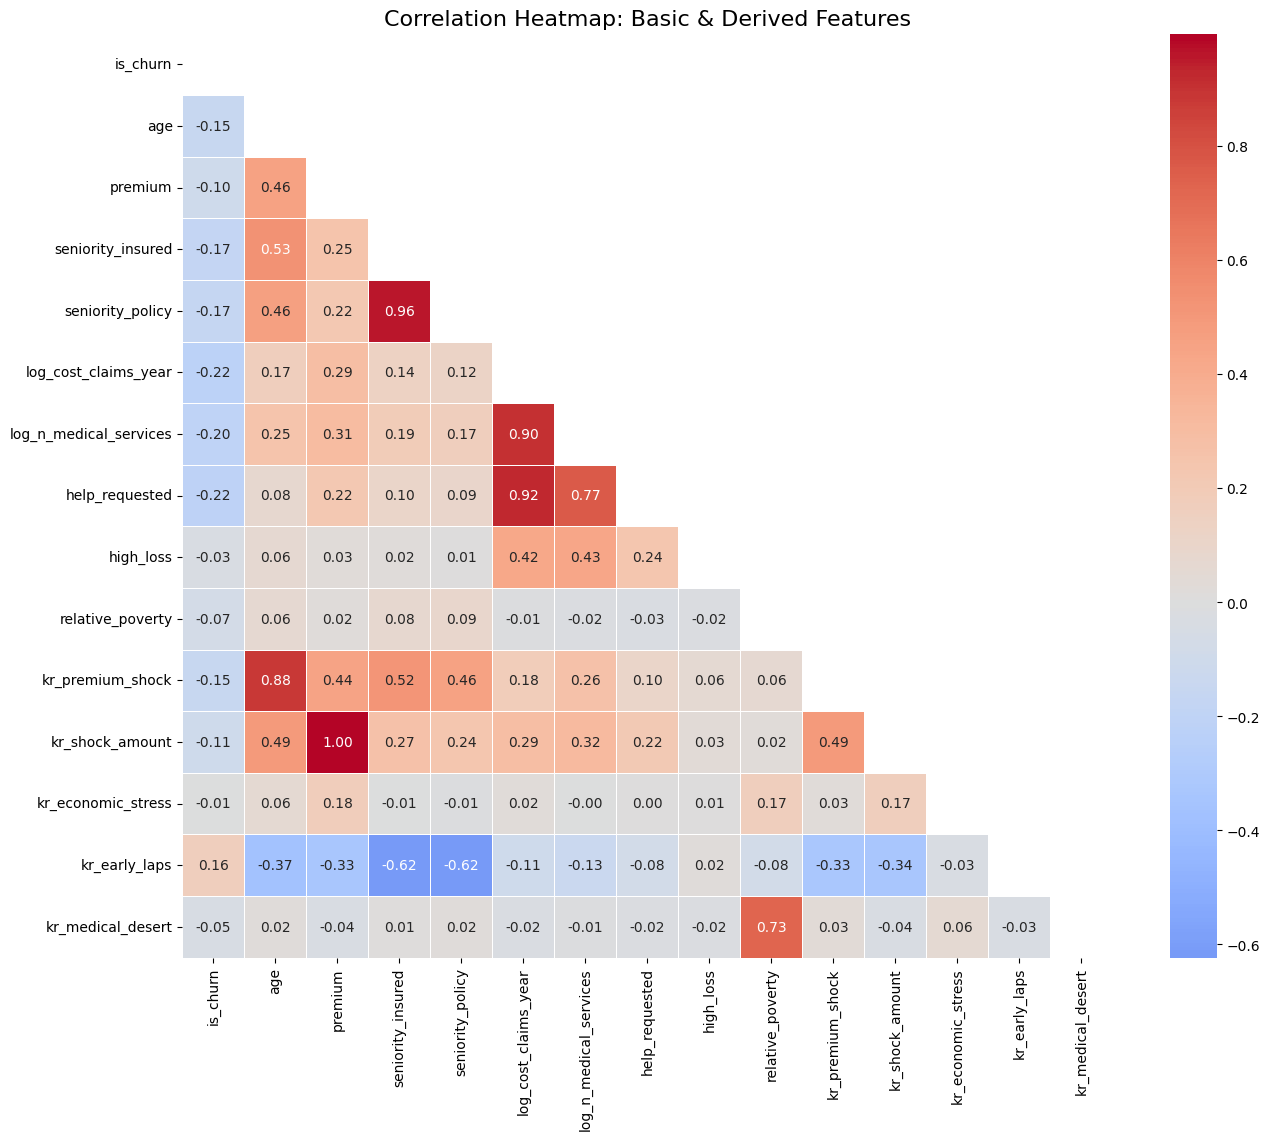

In [ ]:
### 상관관계 확인 - 기본&파생
target = ["is_churn"]
basic_cols = ['age', 'premium', 'seniority_insured', 'seniority_policy', 'log_cost_claims_year', 'log_n_medical_services']
plot_cols = target + basic_cols + der_cols

corr_matrix = data[plot_cols].corr()

plt.figure(figsize = (15, 12))
mask =  np.triu(np.ones_like(corr_matrix, dtype = bool))
sns.heatmap(corr_matrix,
            mask = mask,
            annot = True,
            fmt = ".2f",
            cmap = "coolwarm",
            center = 0,
            linewidths = 0.5)

plt.title('Correlation Heatmap: Basic & Derived Features', fontsize=16)
plt.show()

- `seniority_insured` 제거
- `kr_shock_amount` 제거하고 `kr_premium_shock` 만 포함
- `log_n_medical_services`, `help_requested` 제거하고 `log_cost_claims_year`만 포함

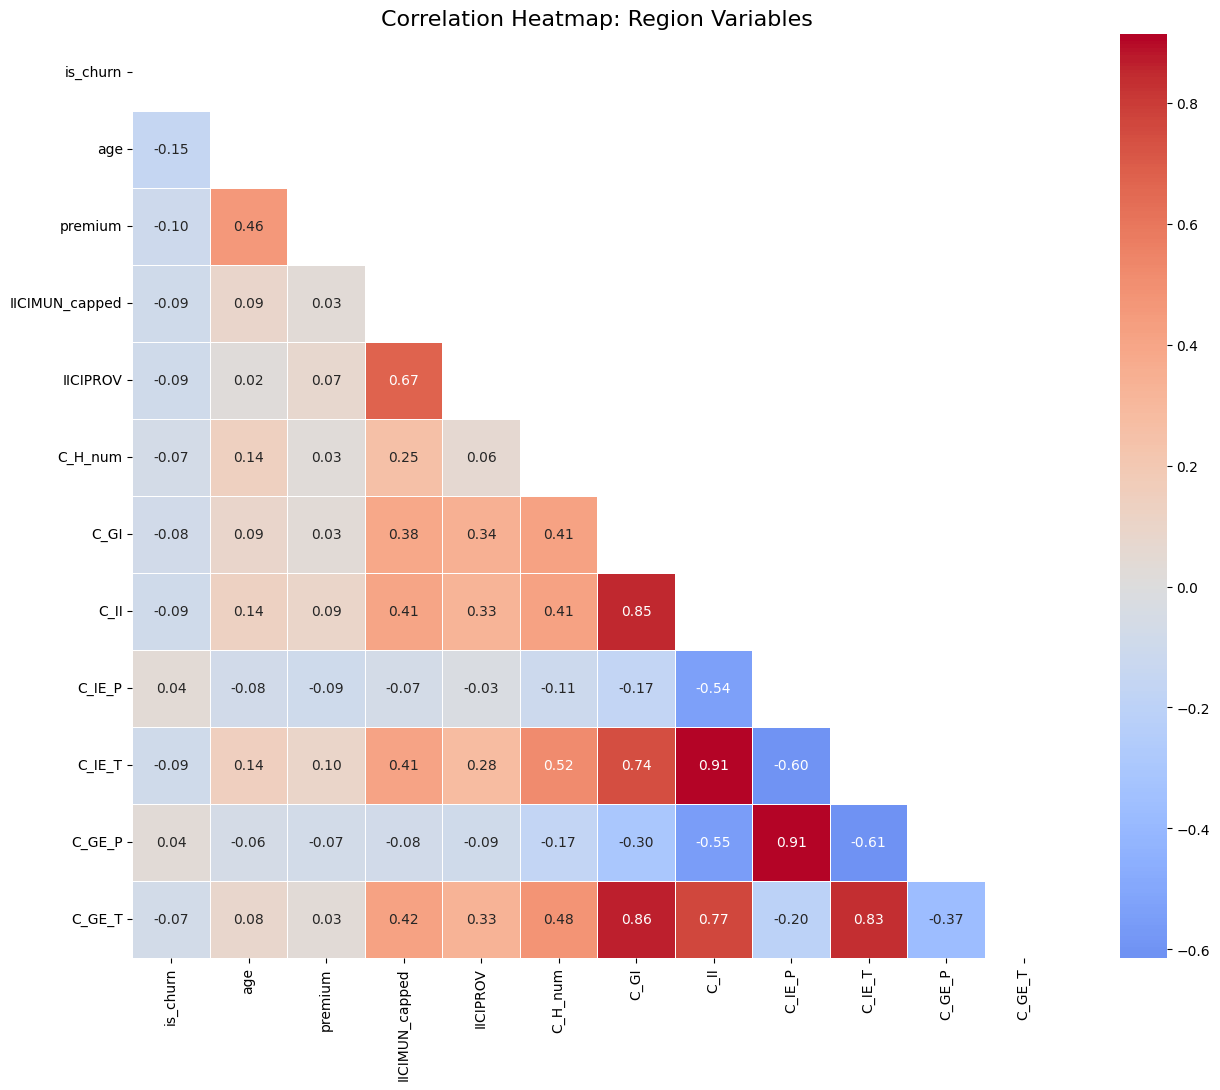

In [ ]:
### 상관관계 확인 - 지역 관련
target = ["is_churn"]
basic_cols = ['age', 'premium', 'IICIMUN_capped', 'IICIPROV', 'C_H_num', 'C_GI', 'C_II', 'C_IE_P', 'C_IE_T', 'C_GE_P', 'C_GE_T']
plot_cols = target + basic_cols

corr_matrix = data[plot_cols].corr()

plt.figure(figsize = (15, 12))
mask =  np.triu(np.ones_like(corr_matrix, dtype = bool))
sns.heatmap(corr_matrix,
            mask = mask,
            annot = True,
            fmt = ".2f",
            cmap = "coolwarm",
            center = 0,
            linewidths = 0.5)

plt.title('Correlation Heatmap: Region Variables', fontsize=16)
plt.show()

- `C_IE_P`, `C_GE_P`, `C_GE_T`, `C_II` 제거하고 `C_GI`, `C_IE_T` 유지
- (여차하면) `IICIMUN`, `C_H_num` 제거

Text(0.5, 1.0, "Cramer's V (Categorical Correlation)")

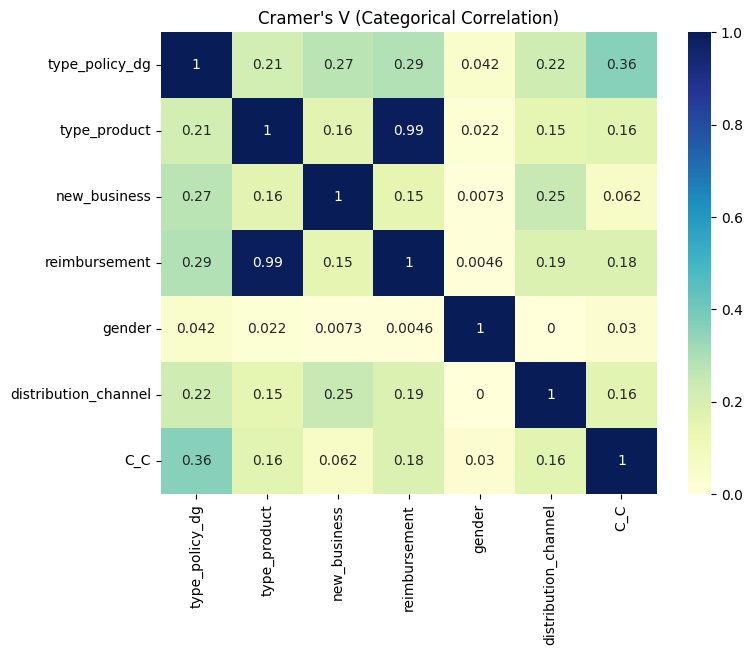

In [ ]:
### 범주형 상관계수 확인
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

cat_cols = ['type_policy_dg', 'type_product', 'new_business', 'reimbursement', 'gender', 'distribution_channel', 'C_C']
v_matrix = pd.DataFrame(index = cat_cols, columns = cat_cols)

for col1 in cat_cols:
    for col2 in cat_cols:
        v_matrix.loc[col1, col2] = cramers_v(data[col1], data[col2])

plt.figure(figsize = (8,6))
sns.heatmap(v_matrix.astype(float), annot = True, cmap = 'YlGnBu')
plt.title("Cramer's V (Categorical Correlation)")

- `reimbursement` 제거

**최종 요약**
- `seniority_insured` 제거
- `kr_shock_amount` 제거하고 `kr_premium_shock` 만 포함
- `log_n_medical_services`, `help_requested` 제거하고 `log_cost_claims_year`만 포함

- `C_IE_P`, `C_GE_P`, `C_GE_T`, `C_II` 제거하고 `C_GI`, `C_IE_T` 유지
- (여차하면) `IICIMUN`, `C_H_num` 제거


- `reimbursement` 제거

##### 데이터 불균형

In [ ]:
data['is_churn'].value_counts(normalize = True)

,proportion
is_churn,
0,0.819492
1,0.180508


In [ ]:
data.to_pickle("DATA/Health_Insurance_final.pkl")

### 최종 설정

In [5]:
data = pd.read_pickle("DATA/Health_Insurance_final.pkl")

In [6]:
target = 'is_churn'

x_cols = [
    # 기본
    'premium', 'seniority_policy', 'type_policy_dg', 'type_product', 'new_business',
    'log_cost_claims_year', 'distribution_channel',
    # 나이 관련
    'age',
    # 성별 관련
    'gender',
    # 지역 관련
    'IICIMUN_capped', 'IICIPROV', 'C_C', 'C_H_num', 'C_GI', 'C_IE_T',
]

der_cols = [
    'missing_geo_cxt',       # 지역 결측 신호
    'high_loss',                  # 보험사 손해율
    'relative_poverty',        # 지역 내 상대적 빈곤
    'kr_premium_shock',   # 가격 인상 압박(비율 단위)
    'kr_economic_stress',  # 소득 대비 체감 부담
    # 'kr_retention_years',    # 장기 유지 혜택
    'kr_early_laps',             #신계약 위험 구간
    # 'kr_direct_channel',     # 가입 채널 영향
    'kr_medical_desert'     # 인프라 취약성
]

print(f"사용 변수 개수(기본) : {len(x_cols)}")
print(f"사용 변수 개수(파생) : {len(der_cols)}")
x_cols += der_cols
print(f"최종 변수 개수 : {len(x_cols)}개")

device = "cuda" if torch.cuda.is_available() else "cpu"

사용 변수 개수(기본) : 15
사용 변수 개수(파생) : 7
최종 변수 개수 : 22개


In [7]:
print("연도별 해지율")
print(data.groupby('period')['is_churn'].mean())
print("\n연도별 1년치 고객 비중")
n_row_id = pd.DataFrame(data.groupby('ID')['is_churn'].count().reset_index(name = 'row_count'))
data['total_years'] = data['ID'].map(n_row_id.set_index('ID')['row_count'])
dist_table = pd.crosstab(data['period'], data['total_years'], normalize = 'index')
print(dist_table)

연도별 해지율
period
2017    0.189977
2018    0.190435
2019    0.161167
Name: is_churn, dtype: float64

연도별 1년치 고객 비중
total_years         1         2         3
period                                   
2017         0.160464  0.128617  0.710919
2018         0.019680  0.230204  0.750116
2019         0.179841  0.091784  0.728376


In [8]:
### Encoding
cat_cols = ['type_policy_dg', 'type_product', 'new_business', 'distribution_channel', 'gender', 'C_C', 'kr_early_laps']

In [9]:
### train/test split
for col in cat_cols:
    data[col] = data[col].astype(str).astype('category')

train = data[data['period'].isin([2017, 2018])]
test = data[data['period'] == 2019]

x_train = train[x_cols]
y_train = train[target]
x_test = test[x_cols]
y_test = test[target]

### Modeling

#### XGBoost

In [10]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, f1_score, recall_score, precision_score, roc_auc_score, average_precision_score

# 원-핫 인코딩 적용 (SHAP 해석을 위해)
x_train_enc = pd.get_dummies(x_train, columns = cat_cols, drop_first = True)
x_test_enc = pd.get_dummies(x_test, columns = cat_cols, drop_first = True)

# ! pip install category_encoders
# from category_encoders import TargetEncoder
# encoder = TargetEncoder(cols = cat_cols, smoothing = 10)
# x_train_enc = encoder.fit_transform(x_train, y_train)
# x_test_enc = encoder.transform(x_test)

# 불균형 데이터 가중치 계산
spw = (y_train == 0).sum() / (y_train == 1).sum()

# 모델 정의
xgb_model = XGBClassifier(
    n_estimators = 500,
    learning_rate = 0.05,
    max_depth = 10,
    scale_pos_weight = spw,  # 데이터 불균형 처리
    random_state = 1742,
    eval_metric = 'logloss',
    tree_method = 'hist',
    device = device
)

# 모델 학습
xgb_model.fit(x_train_enc, y_train)

# 추론
y_pred_xgb = xgb_model.predict(x_test_enc)
y_prob_xgb = xgb_model.predict_proba(x_test_enc)[:, 1]

# 성능 확인
print("--- 2019년 Test 데이터 평가 결과 ---")
print(classification_report(y_test, y_pred_xgb))
f1 = f1_score(y_test, y_pred_xgb)
recall = recall_score(y_test, y_pred_xgb)
precision = precision_score(y_test, y_pred_xgb)

print(f"Final Results (Lapsed Class):")
print(f"- Precision (정밀도): {precision:.4f}")
print(f"- Recall (재현율): {recall:.4f}")
print(f"- F1-Score: {f1:.4f}")

/usr/local/lib/python3.12/dist-packages/xgboost/core.py:553: UserWarning: [09:05:26] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


--- 2019년 Test 데이터 평가 결과 ---
              precision    recall  f1-score   support

           0       0.89      0.85      0.87     63472
           1       0.36      0.44      0.40     12195

    accuracy                           0.78     75667
   macro avg       0.62      0.64      0.63     75667
weighted avg       0.80      0.78      0.79     75667

Final Results (Lapsed Class):
- Precision (정밀도): 0.3611
- Recall (재현율): 0.4391
- F1-Score: 0.3963


#### CatBoost

In [ ]:
!pip install catboost
from catboost import CatBoostClassifier

device_cat = "GPU" if torch.cuda.is_available() else "CPU"

# 불균형 데이터 가중치 계산
spw = (y_train == 0).sum() / (y_train == 1).sum()

# 모델 정의
cat_model = CatBoostClassifier(
    iterations = 500,
    learning_rate = 0.05,
    depth = 7,
    scale_pos_weight = spw,
    random_state = 1742,
    verbose = 100,
    cat_features = cat_cols,
    task_type = device_cat
)

# 모델 학습
cat_model.fit(x_train, y_train, eval_set = (x_test, y_test))

# 추론
# y_prob_cat = cat_model.predict_proba(x_test)[:, 1]
# y_pred_cat = (y_prob_cat >= (y_train == 1).sum() / (y_train == 0).sum())
y_pred_cat = cat_model.predict(x_test)

# 성능 확인
print("--- 2019년 Test 데이터 평가 결과 ---")
print(classification_report(y_test, y_pred_cat))
f1 = f1_score(y_test, y_pred_cat)
recall = recall_score(y_test, y_pred_cat)
precision = precision_score(y_test, y_pred_cat)

print(f"Final Results (Lapsed Class):")
print(f"- Precision (정밀도): {precision:.4f}")
print(f"- Recall (재현율): {recall:.4f}")
print(f"- F1-Score: {f1:.4f}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.4 MB/s eta 0:00:00
0:	learn: 0.6821066	test: 0.6850904	best: 0.6850904 (0)	total: 46.9ms	remaining: 23.4s
100:	learn: 0.5565407	test: 0.5928570	best: 0.5928570 (100)	total: 2.86s	remaining: 11.3s
200:	learn: 0.5422524	test: 0.5879829	best: 0.5879829 (200)	total: 5.49s	remaining: 8.17s
300:	learn: 0.5310766	test: 0.5868228	best: 0.5868092 (289)	total: 8.17s	remaining: 5.4s
400:	learn: 0.5219148	test: 0.5870012	best: 0.5865780 (336)	total: 13.7s	remaining: 3.37s
499:	learn: 0.5136255	test: 0.5879333	best: 0.5865780 (336)	total: 16.3s	remaining: 0us
bestTest = 0.5865779532
bestIteration = 336
Shrink model to first 337 iterations.
--- 2019년 Test 데이터 평가 결과 ---
              precision    recall  f1-score   support

           0       0.91      0.72      0.80     63472
           1       0.30      0.64      0.41     12195

    accuracy                           0.71     75667
   macro avg       0.61      0.68      0.61     75667
weigh

In [ ]:
# 모델 정보 저장
import joblib

model_data = {
    'model': cat_model,
    'feature_names': x_cols,
    'cat_features': cat_cols,
    'threshold': 0.5
}
joblib.dump(model_data, "Model/cat_package0.pkl")

joblib.dump(y_pred_cat, "Model/cat_pred0.pkl")

['Model/cat_pred0.pkl']

#### LightGBM

In [11]:
import lightgbm as lgb
from sklearn.metrics import classification_report, average_precision_score

device_lgbm = "gpu" if torch.cuda.is_available() else "cpu"

x_train_lgbm = x_train.copy()
x_test_lgbm = x_test.copy()

# 범주형 타입 변환
for col in cat_cols:
    x_train_lgbm[col] = x_train_lgbm[col].astype('category')
    x_test_lgbm[col] = x_test_lgbm[col].astype('category')

# 불균형 데이터 가중치 계산
spw = (y_train == 0).sum() / (y_train == 1).sum()

# 모델 정의
lgb_model = lgb.LGBMClassifier(
    n_estimators = 500,
    learning_rate = 0.05,
    max_depth = 10,
    scale_pos_weight = spw,
    random_state = 1742,
    importance_type = 'gain',
    verbosity = -1,
    device = device_lgbm
)

# 모델 학습
lgb_model.fit(x_train_lgbm, y_train, eval_set = [(x_test_lgbm, y_test)], categorical_feature = cat_cols)

# 추론
y_pred_lgb = lgb_model.predict(x_test_lgbm)

# 성능 확인
print("--- 2019년 Test 데이터 평가 결과 ---")
print(classification_report(y_test, y_pred_lgb))
f1 = f1_score(y_test, y_pred_lgb)
recall = recall_score(y_test, y_pred_lgb)
precision = precision_score(y_test, y_pred_lgb)

print(f"Final Results (Lapsed Class):")
print(f"- Precision (정밀도): {precision:.4f}")
print(f"- Recall (재현율): {recall:.4f}")
print(f"- F1-Score: {f1:.4f}")

--- 2019년 Test 데이터 평가 결과 ---
              precision    recall  f1-score   support

           0       0.90      0.74      0.82     63472
           1       0.31      0.59      0.40     12195

    accuracy                           0.72     75667
   macro avg       0.60      0.67      0.61     75667
weighted avg       0.81      0.72      0.75     75667

Final Results (Lapsed Class):
- Precision (정밀도): 0.3055
- Recall (재현율): 0.5906
- F1-Score: 0.4027


#### TabPFN

In [ ]:
!pip install -q tabpfn tabpfn-client huggingface_hub
!pip install tabpfn --upgrade

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.7/57.7 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 42.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.5/78.5 kB 7.1 MB/s eta 0:00:00


In [ ]:
import tabpfn_client
from tabpfn_client import TabPFNClassifier, TabPFNRegressor, set_access_token
import os
from google.colab import userdata

# 시스템 환경 변수 설정
TABPFN_TOKEN = userdata.get("TABPFN_TOKEN")
tabpfn_client.set_access_token(TABPFN_TOKEN)
os.environ["TABPFN_TOKEN"] = userdata.get("TABPFN_TOKEN")
os.environ["HF_TOKEN"] = userdata.get("HF_TOKEN")

# 설정 확인
print(f"-> TABPFN_TOKEN 설정 여부: {'TABPFN_TOKEN' in os.environ}")
print(f"-> HF_TOKEN 설정 여부: {'HF_TOKEN' in os.environ}")

# 라이브러리 불러오기
import tabpfn
from tabpfn import TabPFNClassifier
print(tabpfn.__version__)
try:
    x_train = np.random.rand(100, 5)
    y_train = np.random.randint(0, 2, 100)

    x_test = np.random.rand(10, 5)

    classifier = TabPFNClassifier()
    classifier.fit(x_train, y_train)

    print("인증 성공..!")
except Exception as e:
    print("아직...")
    print(f"{e}")

✅ TABPFN_TOKEN 설정 여부: True
✅ HF_TOKEN 설정 여부: True
7.1.1


tabpfn-v2.6-classifier-v2.6_default.ckpt:   0%|          | 0.00/43.0M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/35.0 [00:00<?, ?B/s]

인증 성공..!


In [ ]:
from tabpfn import TabPFNClassifier
from sklearn.metrics import classification_report, average_precision_score

device_tab = "cuda" if torch.cuda.is_available() else "cpu"

tab_model = TabPFNClassifier(
    device = device
)

n_samples = 20000
x_train_small = x_train.sample(n = n_samples, random_state = 1743)
y_train_small = y_train.loc[x_train_small.index]

tab_model.fit(x_train_small, y_train_small)

y_pred_tab = tab_model.predict(x_test)

# 성능 확인
print("--- 2019년 Test 데이터 평가 결과 ---")
print(classification_report(y_test, y_pred_tab))
f1 = f1_score(y_test, y_pred_tab)
recall = recall_score(y_test, y_pred_tab)
precision = precision_score(y_test, y_pred_tab)

print(f"Final Results (Lapsed Class):")
print(f"- Precision (정밀도): {precision:.4f}")
print(f"- Recall (재현율): {recall:.4f}")
print(f"- F1-Score: {f1:.4f}")

--- 2019년 Test 데이터 평가 결과 ---
              precision    recall  f1-score   support

           0       0.85      0.99      0.91     63472
           1       0.61      0.09      0.16     12195

    accuracy                           0.84     75667
   macro avg       0.73      0.54      0.54     75667
weighted avg       0.81      0.84      0.79     75667

Final Results (Lapsed Class):
- Precision (정밀도): 0.6114
- Recall (재현율): 0.0918
- F1-Score: 0.1597


### Model Tuning

#### XGBoost Tuning

In [14]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, f1_score, recall_score, precision_score, roc_auc_score, average_precision_score, precision_recall_curve

! pip install optuna
! pip install "optuna-integration[xgboost]"
import optuna
from optuna.samplers import TPESampler
from optuna.pruners import MedianPruner
from optuna.integration import XGBoostPruningCallback

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 21.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 103.4/103.4 kB 5.4 MB/s eta 0:00:00


/usr/lib/python3.12/importlib/__init__.py:90: FutureWarning: `optuna.integration.xgboost` has been deprecated in v4.9.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v4.9.0. Use `optuna_integration.xgboost` instead.
  return _bootstrap._gcd_import(name[level:], package, level)


In [ ]:
# 불균형 데이터 가중치 계산
spw = (y_train == 0).sum() / (y_train == 1).sum()
device = "cuda" if torch.cuda.is_available() else "cpu"

In [ ]:
# optuna로 하이퍼파라미터 튜닝
data_cat = data.copy()

train_2017 = data_cat[data_cat['period'] == 2017].copy()
val_2018 = data_cat[data_cat['period'] == 2018].copy()

x_train = train_2017[x_cols]
y_train = train_2017[target]
x_val = val_2018[x_cols]
y_val = val_2018[target]

def objective(trial):
    params = {
        # 모델 복잡도 제어
        'n_estimators': 2000,
        'max_depth': trial.suggest_int('max_depth', 9, 11),
        'learning_rate': trial.suggest_float('learning_rate', 0.03, 0.05, log=True),
        'max_bin': trial.suggest_categorical('max_bin', [256, 512]),

        # 과적합 방지
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 3),
        'subsample': trial.suggest_float('subsample', 0.6, 0.8),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 0.8),

        # 정규화
        'gamma': trial.suggest_float('gamma', 1e-8, 1.0, log=True),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.1, 1.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 0.1, log=True),

        # 불균형
        'scale_pos_weight': spw,
        'eval_metric': 'aucpr',
        'tree_method': 'hist',
        'enable_categorical': True,
        'early_stopping_rounds': 100,
        'device': device,
        'random_state': 1746,
        'verbosity': 0
    }

    pruning_callback = optuna.integration.XGBoostPruningCallback(trial, 'validation_0-aucpr')

    model = XGBClassifier(**params, callbacks = [pruning_callback])
    model.fit(
        x_train, y_train,
        eval_set = [(x_val, y_val)],
        verbose = False)

    # best_iteration 저장해두기
    trial.set_user_attr("best_iteration", model.best_iteration)

    y_prob = model.predict_proba(x_val)[:, 1]
    aucpr = average_precision_score(y_val, y_prob)

    return aucpr

sampler = TPESampler(seed = 1746)
pruner = MedianPruner(n_warmup_steps = 10) # 초기 10회 이후 성적이 안 좋으면 조기 종료

study = optuna.create_study(direction = 'maximize', sampler = sampler, pruner = pruner, study_name = 'xgboost_cat_optimization')
study.optimize(lambda trial: objective(trial), n_trials = 1500, timeout = 3600*2)

print(f"Best value: {study.best_value}")
print(f"Best parameters: {study.best_params}")
print(f"Best trial: {study.best_trial}")

[I 2026-06-12 05:20:47,843] A new study created in memory with name: xgboost_cat_optimization
[I 2026-06-12 05:20:53,309] Trial 0 finished with value: 0.34546145346622414 and parameters: {'max_depth': 11, 'learning_rate': 0.031025414018621893, 'max_bin': 256, 'min_child_weight': 3, 'subsample': 0.7258518238080189, 'colsample_bytree': 0.6732518053801367, 'gamma': 0.5312647704159154, 'reg_alpha': 0.45573087074547364, 'reg_lambda': 0.03943013779456079}. Best is trial 0 with value: 0.34546145346622414.
[I 2026-06-12 05:20:57,488] Trial 1 finished with value: 0.3350167164410527 and parameters: {'max_depth': 9, 'learning_rate': 0.04833825236860716, 'max_bin': 512, 'min_child_weight': 3, 'subsample': 0.7090514110564388, 'colsample_bytree': 0.6321635842931587, 'gamma': 0.0006578988640700843, 'reg_alpha': 0.6065968795604303, 'reg_lambda': 0.015556795184767673}. Best is trial 0 with value: 0.34546145346622414.
[I 2026-06-12 05:21:01,349] Trial 2 finished with value: 0.3662946917956774 and parame

In [ ]:
def threshold_tuning(x_train, x_val, y_train, y_val, xgb_model):

    # 모델 학습
    xgb_model.fit(x_train, y_train, eval_set=[(x_val, y_val)], verbose = False)

    # 추론
    y_prob = xgb_model.predict_proba(x_val)[:, 1]

    # 성능 확인
    precisions, recalls, thresholds = precision_recall_curve(y_val, y_prob)

    # F1-Score 기준으로 튜닝
    f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-9)
    best_idx = np.argmax(f1_scores)
    best_threshold = thresholds[best_idx]

    # 최종 예측값
    y_pred_best = (y_prob >= best_threshold).astype(int)

    aucpr = average_precision_score(y_val, y_prob)

    print(f"Best Threshold: {best_threshold:.4f}")
    print(f"Best F1-Score: {f1_scores[best_idx]:.4f}")
    print(f"Best PR-AUC: {aucpr:.4f}")
    print(f"Best Recall: {recalls[best_idx]:.4f}")
    print(f"Best Precision: {precisions[best_idx]:.4f}")

    return best_threshold, xgb_model

fixed_params = {
    'n_estimators': 275,
    'scale_pos_weight': spw,
    'tree_method': 'hist',
    'device': device,
    'random_state': 1746,
    'eval_metric': 'aucpr',
    'early_stopping_rounds': 100
}

final_params = {**study.best_params, **fixed_params}

init_xgb = XGBClassifier(**final_params, enable_categorical = True)

best_threshold, xgb_model = threshold_tuning(x_train, x_val, y_train, y_val, init_xgb)

Best Threshold: 0.4909
Best F1-Score: 0.4103
Best PR-AUC: 0.4043
Best Recall: 0.4944
Best Precision: 0.3507


In [ ]:
# 모델 정보 저장
import joblib

model_data = {
    'model': xgb_model,
    'feature_names': x_cols,
    'threshold': best_threshold,
    'fixed_params': fixed_params,
    'best_params': study.best_params
}
joblib.dump(model_data, "Model/xgb_package2.pkl")

joblib.dump(y_pred, "Model/xgb_pred2.pkl")

['Model/xgb_pred2.pkl']

#### CatBoost Tuning

In [ ]:
!pip install catboost
from catboost import CatBoostClassifier, Pool
from sklearn.metrics import classification_report, f1_score, recall_score, precision_score, roc_auc_score, average_precision_score, precision_recall_curve

! pip install optuna
import optuna

In [ ]:
# # 원-핫 인코딩 적용 (SHAP 해석을 위해)
# x_train_enc = pd.get_dummies(x_train, columns = cat_cols, drop_first = True)
# x_test_enc = pd.get_dummies(x_test, columns = cat_cols, drop_first = True)

# 불균형 데이터 가중치 계산
spw = (y_train == 0).sum() / (y_train == 1).sum()

device_cat = "GPU" if torch.cuda.is_available() else "CPU"

In [ ]:
# optuna로 하이퍼파라미터 튜닝
def objective(trial):
    params = {
        # 1. 반복 횟수 및 학습률
        'iterations': trial.suggest_int('iterations', 100, 2000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),

        # 2. 나무의 깊이
        'depth': trial.suggest_int('depth', 3, 8),

        # 3. 정규화 및 샘플링
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 10),
        'bootstrap_type': 'Bernoulli',
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        # 'colsample_bylevel': trial.suggest_float('colsample_bylevel', 0.5, 1.0),
        'rsm': 1.0,
        'random_strength': trial.suggest_float('random_strength', 0, 10),

        # 4. 불균형 데이터 처리
        'scale_pos_weight': spw,

        # 5. 기타 설정
        'eval_metric': 'TotalF1',
        'early_stopping_rounds': 50,
        'task_type': device_cat,
        'verbose': False,
        'random_seed': 1743,
    }

    train_2017 = data[data['period'] == 2017]
    x_train_2017 = train_2017[x_cols]
    y_train_2017 = train_2017[target]

    val_2018 = data[data['period'] == 2018]
    x_val_2018 = val_2018[x_cols]
    y_val_2018 = val_2018[target]

    train_pool = Pool(x_train, y_train, cat_features = cat_cols)
    val_pool = Pool(x_val_2018, y_val_2018, cat_features = cat_cols)

    model = CatBoostClassifier(**params)
    model.fit(train_pool, eval_set = val_pool)

    y_prob = model.predict_proba(x_val_2018)[:, 1]
    aucpr = average_precision_score(y_val_2018, y_prob)

    return aucpr


study = optuna.create_study(direction = 'maximize')
study.optimize(objective, n_trials = 50)

print(f"Best value: {study.best_value}")
print(f"Best parameters: {study.best_params}")
print(f"Best trial: {study.best_trial}")

[I 2026-05-07 14:18:35,128] A new study created in memory with name: no-name-669cbf01-059f-4b23-9567-7e450dc36c40
[I 2026-05-07 14:18:50,839] Trial 0 finished with value: 0.5366936449878286 and parameters: {'iterations': 249, 'learning_rate': 0.02021462601714659, 'depth': 4, 'l2_leaf_reg': 7.157501359716404, 'subsample': 0.8391979927063027, 'random_strength': 4.578798240839745}. Best is trial 0 with value: 0.5366936449878286.
[I 2026-05-07 14:19:33,649] Trial 1 finished with value: 0.6355292405284005 and parameters: {'iterations': 1821, 'learning_rate': 0.07495745108945553, 'depth': 4, 'l2_leaf_reg': 1.4558665688473438, 'subsample': 0.9154865452981877, 'random_strength': 4.763952307347374}. Best is trial 1 with value: 0.6355292405284005.
[I 2026-05-07 14:20:24,903] Trial 2 finished with value: 0.6068703587793474 and parameters: {'iterations': 1013, 'learning_rate': 0.015089805845919428, 'depth': 8, 'l2_leaf_reg': 4.983657598047646, 'subsample': 0.5206465456312434, 'random_strength': 5.

Best value: 0.8877993286474251
Best parameters: {'iterations': 1998, 'learning_rate': 0.09894677633604154, 'depth': 8, 'l2_leaf_reg': 5.0189686612659425, 'subsample': 0.6312253830760631, 'random_strength': 7.372354756173392}
Best trial: FrozenTrial(number=21, state=<TrialState.COMPLETE: 1>, values=[0.8877993286474251], datetime_start=datetime.datetime(2026, 5, 7, 14, 34, 44, 809335), datetime_complete=datetime.datetime(2026, 5, 7, 14, 36, 16, 182998), params={'iterations': 1998, 'learning_rate': 0.09894677633604154, 'depth': 8, 'l2_leaf_reg': 5.0189686612659425, 'subsample': 0.6312253830760631, 'random_strength': 7.372354756173392}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'iterations': IntDistribution(high=2000, log=False, low=100, step=1), 'learning_rate': FloatDistribution(high=0.1, log=True, low=0.01, step=None), 'depth': IntDistribution(high=8, log=False, low=3, step=1), 'l2_leaf_reg': FloatDistribution(high=10.0, log=False, low=1.0, step=None), 'subs

In [ ]:
cat_model = CatBoostClassifier(**study.best_params)
cat_model.fit(x_train, y_train, cat_features = cat_cols, verbose = False)

# 추론
y_pred_cat = cat_model.predict(x_test)

# 성능 확인
print("--- 2019년 Test 데이터 평가 결과 ---")
print(classification_report(y_test, y_pred_cat))
f1 = f1_score(y_test, y_pred_cat)
recall = recall_score(y_test, y_pred_cat)
precision = precision_score(y_test, y_pred_cat)

print(f"Final Results (Lapsed Class):")
print(f"- Precision (정밀도): {precision:.4f}")
print(f"- Recall (재현율): {recall:.4f}")
print(f"- F1-Score: {f1:.4f}")

--- 2019년 Test 데이터 평가 결과 ---
              precision    recall  f1-score   support

           0       0.86      0.96      0.91     63472
           1       0.46      0.17      0.25     12195

    accuracy                           0.83     75667
   macro avg       0.66      0.57      0.58     75667
weighted avg       0.79      0.83      0.80     75667

Final Results (Lapsed Class):
- Precision (정밀도): 0.4601
- Recall (재현율): 0.1693
- F1-Score: 0.2476


In [ ]:
def threshold_tuning(x_train, x_test, y_train, y_test, cat_model, cat_features = cat_cols):

    # 모델 학습
    cat_model.fit(x_train, y_train, cat_features = cat_features, verbose = False)

    # 추론
    y_prob = cat_model.predict_proba(x_test)[:, 1]

    # 성능 확인
    precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob)

    # F1-Score 기준으로 튜닝
    f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-9)
    best_idx = np.argmax(f1_scores)
    best_threshold = thresholds[best_idx]
    best_f1 = f1_scores[best_idx]

    # 최종 예측값
    y_pred_best = (y_prob >= best_threshold).astype(int)

    print(f"Best Threshold: {best_threshold:.4f}")
    print(f"Best F1-Score: {f1_scores[best_idx]:.4f}")
    print(f"Best Recall: {recalls[best_idx]:.4f}")
    print(f"Best Precision: {precisions[best_idx]:.4f}")

    return best_threshold, y_pred_best

cat_model = CatBoostClassifier(**study.best_params)
best_threshold, y_pred = threshold_tuning(x_train, x_test, y_train, y_test, cat_model, cat_features = cat_cols)

Best Threshold: 0.2052
Best F1-Score: 0.3997
Best Recall: 0.5164
Best Precision: 0.3260


In [ ]:
y_pred.mean()

np.float64(0.2552896242747829)

In [ ]:
# 모델 정보 저장
import joblib

model_data = {
    'model': cat_model,
    'feature_names': x_cols,
    'cat_features': cat_cols,
    'threshold': best_threshold
}
joblib.dump(model_data, "Model/cat_package1.pkl")

joblib.dump(y_pred, "Model/cat_pred1.pkl")

['Model/cat_pred1.pkl']

#### LightGBM Tuning

In [20]:
import lightgbm
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, average_precision_score

device_lgbm = "gpu" if torch.cuda.is_available() else "cpu"

In [17]:
# optuna로 하이퍼파라미터 튜닝
data_copy = data.copy()
for col in cat_cols:
    data_copy[col] = data_copy[col].astype('category')

train_2017 = data_copy[data_copy['period'] == 2017].copy()
val_2018 = data_copy[data_copy['period'] == 2018].copy()

x_train = train_2017[x_cols]
y_train = train_2017[target]
x_val = val_2018[x_cols]
y_val = val_2018[target]

def objective(trial):
    params = {
        'objective': 'binary',
        'metric': 'average_precision',
        'verbosity': -1,
        'boosting_type': 'gbdt',

        # 1. 반복 횟수 및 학습률
        'n_estimators': trial.suggest_int('n_estimators', 500, 2000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log = True),

        # 2. 나무의 복잡도
        'num_leaves': trial.suggest_int('num_leaves', 7, 256),
        'max_depth': trial.suggest_int('max_depth', 5, 15),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 30),

        # 3. 정규화 및 샘플링
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True), # L1
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True), # L2
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),

        # # 4. 불균형 데이터 처리
        # 'scale_pos_weight': spw,

        'device': device_lgbm,
        'random_state': 1743
    }

    model =LGBMClassifier(**params)
    model.fit(x_train, y_train, eval_set = [(x_val, y_val)],
              categorical_feature=cat_cols,
              callbacks=[
            lgb.early_stopping(stopping_rounds=100),
            lgb.log_evaluation(period=0) # 로그 출력 방지
        ])

    y_prob = model.predict_proba(x_val)[:, 1]
    aucpr = average_precision_score(y_val, y_prob)

    return aucpr

study = optuna.create_study(direction = 'maximize')
study.optimize(objective, n_trials = 100)

print(f"Best value: {study.best_value}")
print(f"Best parameters: {study.best_params}")
print(f"Best trial: {study.best_trial}")

[I 2026-07-15 09:07:16,127] A new study created in memory with name: no-name-bb79fa4e-1aa0-464e-846a-460ba53efc4b


Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[3]	valid_0's average_precision: 0.324836


[I 2026-07-15 09:07:21,616] Trial 0 finished with value: 0.3248357698695241 and parameters: {'n_estimators': 669, 'learning_rate': 0.0572962006944465, 'num_leaves': 160, 'max_depth': 6, 'min_child_samples': 30, 'reg_alpha': 0.11819229798399816, 'reg_lambda': 1.4297702494567182e-05, 'subsample': 0.9379618263922521, 'colsample_bytree': 0.8028094576785968}. Best is trial 0 with value: 0.3248357698695241.


Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[12]	valid_0's average_precision: 0.327974


[I 2026-07-15 09:07:27,884] Trial 1 finished with value: 0.32797356969125785 and parameters: {'n_estimators': 865, 'learning_rate': 0.07224969127407507, 'num_leaves': 208, 'max_depth': 10, 'min_child_samples': 15, 'reg_alpha': 9.792225308017453e-08, 'reg_lambda': 0.01679410312834052, 'subsample': 0.9895489370989243, 'colsample_bytree': 0.7487308683794518}. Best is trial 1 with value: 0.32797356969125785.


...

Early stopping, best iteration is:
[3]	valid_0's average_precision: 0.350784
Training until validation scores don't improve for 100 rounds


[I 2026-07-15 09:12:13,403] Trial 98 finished with value: 0.3355687777603334 and parameters: {'n_estimators': 733, 'learning_rate': 0.15968626085493848, 'num_leaves': 169, 'max_depth': 8, 'min_child_samples': 9, 'reg_alpha': 5.281108870027828e-05, 'reg_lambda': 0.01011433061595934, 'subsample': 0.7286893878804676, 'colsample_bytree': 0.6852333785554304}. Best is trial 97 with value: 0.35078403209417935.


Early stopping, best iteration is:
[3]	valid_0's average_precision: 0.335569
Training until validation scores don't improve for 100 rounds


[I 2026-07-15 09:12:15,919] Trial 99 finished with value: 0.3441624300905321 and parameters: {'n_estimators': 794, 'learning_rate': 0.11537152861059605, 'num_leaves': 165, 'max_depth': 6, 'min_child_samples': 9, 'reg_alpha': 8.807497724183083e-07, 'reg_lambda': 0.0045089537855399105, 'subsample': 0.6748981803412063, 'colsample_bytree': 0.665624088881327}. Best is trial 97 with value: 0.35078403209417935.


Early stopping, best iteration is:
[4]	valid_0's average_precision: 0.344162
Best value: 0.35078403209417935
Best parameters: {'n_estimators': 725, 'learning_rate': 0.11485991071916361, 'num_leaves': 167, 'max_depth': 7, 'min_child_samples': 10, 'reg_alpha': 5.083096558024843e-05, 'reg_lambda': 0.0042061483406222915, 'subsample': 0.7495308481770478, 'colsample_bytree': 0.6364882442015725}
Best trial: FrozenTrial(number=97, state=<TrialState.COMPLETE: 1>, values=[0.35078403209417935], datetime_start=datetime.datetime(2026, 7, 15, 9, 12, 7, 267607), datetime_complete=datetime.datetime(2026, 7, 15, 9, 12, 10, 131580), params={'n_estimators': 725, 'learning_rate': 0.11485991071916361, 'num_leaves': 167, 'max_depth': 7, 'min_child_samples': 10, 'reg_alpha': 5.083096558024843e-05, 'reg_lambda': 0.0042061483406222915, 'subsample': 0.7495308481770478, 'colsample_bytree': 0.6364882442015725}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'n_estimators': IntDistribution(

In [23]:
def threshold_tuning(x_train, x_test, y_train, y_test, lgbm_model):

    # 모델 학습
    lgbm_model.fit(x_train, y_train)

    # 추론
    y_prob = lgbm_model.predict_proba(x_test)[:, 1]

    # 성능 확인
    precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob)

    # F1-Score 기준으로 튜닝
    f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-9)
    best_idx = np.argmax(f1_scores)
    best_threshold = thresholds[best_idx]

    # 최종 예측값
    y_pred_best = (y_prob >= best_threshold).astype(int)

    aucpr = average_precision_score(y_test, y_prob)


    print(f"Best Threshold: {best_threshold:.4f}")
    print(f"Best F1-Score: {f1_scores[best_idx]:.4f}")
    print(f"Best PR-AUC: {aucpr:.4f}")
    print(f"Best Recall: {recalls[best_idx]:.4f}")
    print(f"Best Precision: {precisions[best_idx]:.4f}")

    return best_threshold, y_pred_best

lgbm_model = LGBMClassifier(**study.best_params, verbosity = -1)

best_threshold, y_pred = threshold_tuning(x_train, x_test, y_train, y_test, lgbm_model)

Best Threshold: 0.1532
Best F1-Score: 0.3522
Best PR-AUC: 0.2612
Best Recall: 0.5852
Best Precision: 0.2519
